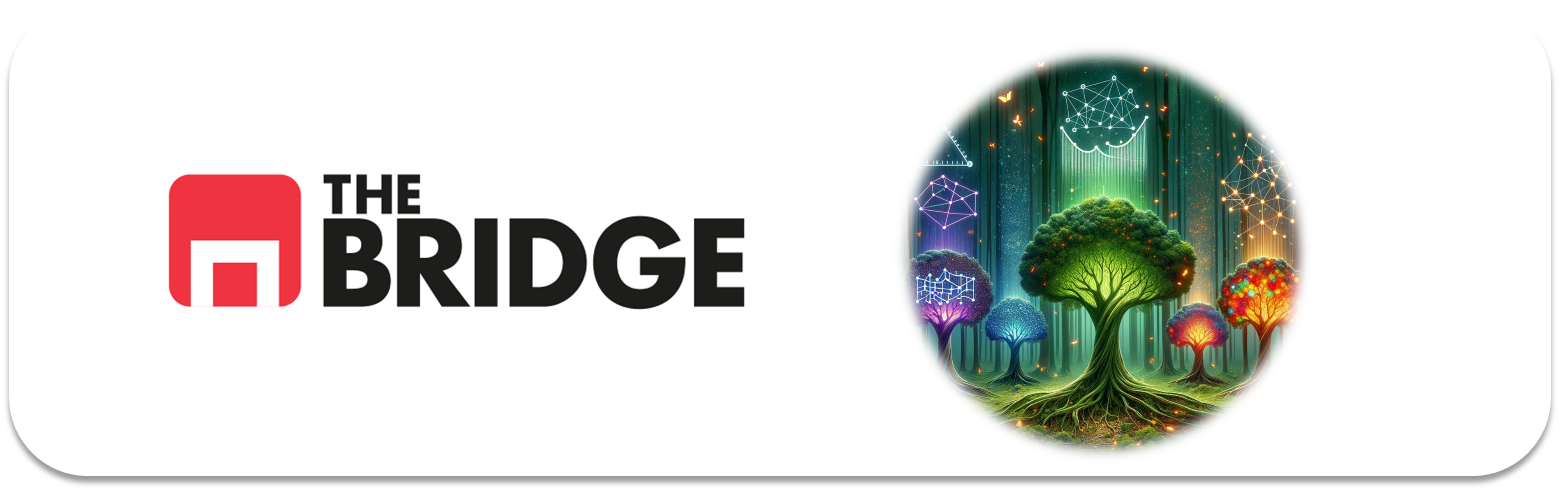

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import bootcampviztools as bt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [3]:
df = pd.read_csv(url, header=None, names=names)
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


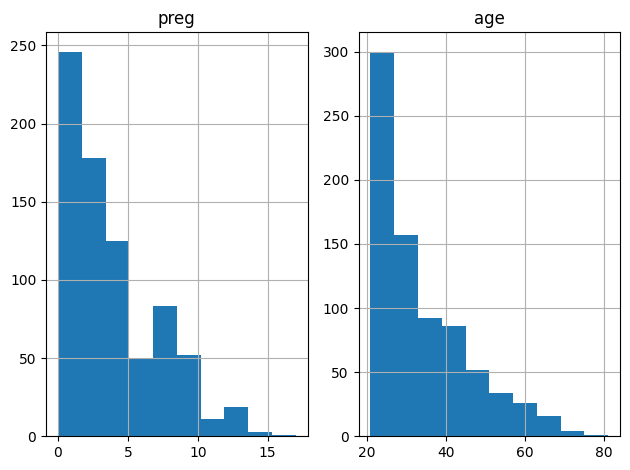

In [6]:
df[["preg", "age"]].hist()
plt.tight_layout()

In [7]:
df.preg.value_counts()

preg
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64

In [8]:
target = "class"
features_num = [c for c in df.columns if c != target]
features_num


['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

#### Distribución target

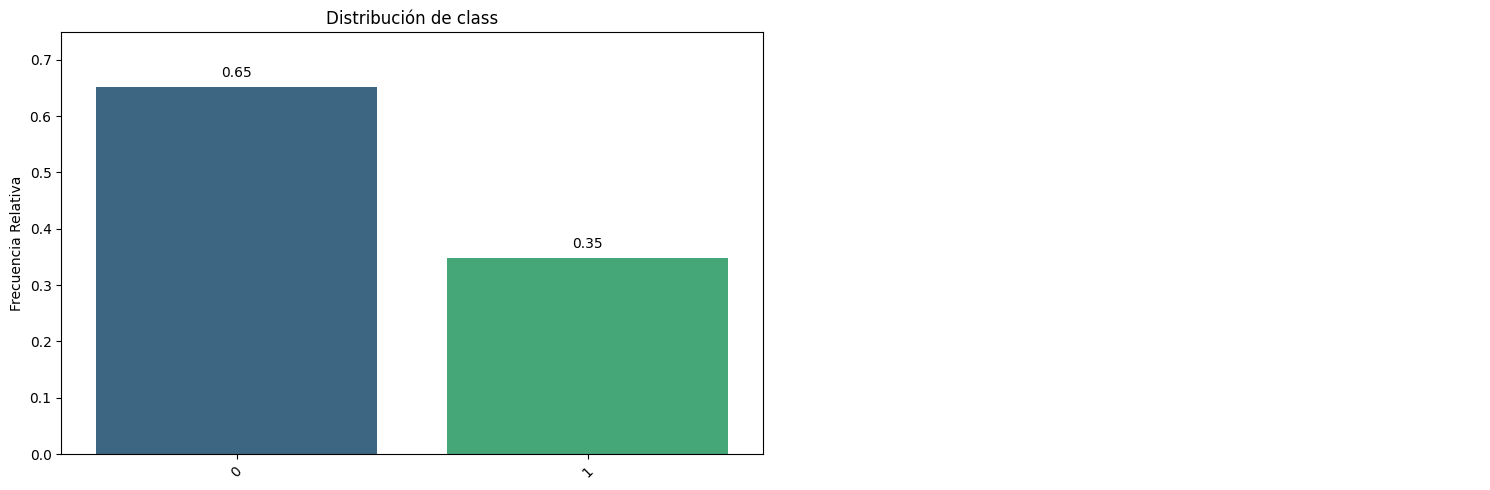

In [9]:
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores=True, relativa=True)

Train / Test

In [10]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])
print("Distribución en train:")
print(train_set[target].value_counts(normalize=True).round(3))
print("\nDistribución en test:")
print(test_set[target].value_counts(normalize=True).round(3))

Distribución en train:
class
0    0.651
1    0.349
Name: proportion, dtype: float64

Distribución en test:
class
0    0.649
1    0.351
Name: proportion, dtype: float64


In [11]:
train_set.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,120.908795,69.442997,20.776873,78.666124,31.973290,0.477428,33.366450,0.348534
std,3.314148,31.561093,18.402581,15.856433,107.736572,7.861364,0.330300,11.833438,0.476895
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,62.500000,0.000000,0.000000,27.500000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.500000,32.300000,0.382500,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000,1.000000


In [ ]:
test_set.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.948052,120.837662,67.759740,19.577922,84.318182,32.069481,0.449740,32.740260,0.350649
std,3.591552,33.670155,22.782018,16.345847,141.595424,7.999807,0.335567,11.487877,0.478730
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,62.500000,0.000000,0.000000,26.425000,0.237000,23.000000,0.000000
50%,3.000000,117.000000,72.000000,22.000000,0.000000,31.600000,0.333000,28.000000,0.000000
75%,6.000000,141.500000,80.000000,32.000000,115.000000,36.600000,0.583000,39.750000,1.000000
max,15.000000,197.000000,106.000000,63.000000,846.000000,59.400000,2.420000,68.000000,1.000000


In [14]:
tienen_nulos = ["plas", "pres", "skin", "test", "mass"]

train_set[tienen_nulos] = train_set[tienen_nulos].replace(0, np.nan)
test_set[tienen_nulos] = test_set[tienen_nulos].replace(0, np.nan)

In [15]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")

train_set[tienen_nulos] = imp.fit_transform(train_set[tienen_nulos])
test_set[tienen_nulos] = imp.transform(test_set[tienen_nulos])

train_set[tienen_nulos].isna().sum()

plas    0
pres    0
skin    0
test    0
mass    0
dtype: int64

In [16]:
train_set.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,121.671010,72.140065,29.042345,137.705212,32.448208,0.477428,33.366450,0.348534
std,3.314148,30.003794,12.275119,8.891855,78.764767,6.824122,0.330300,11.833438,0.476895
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.625000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000,1.000000


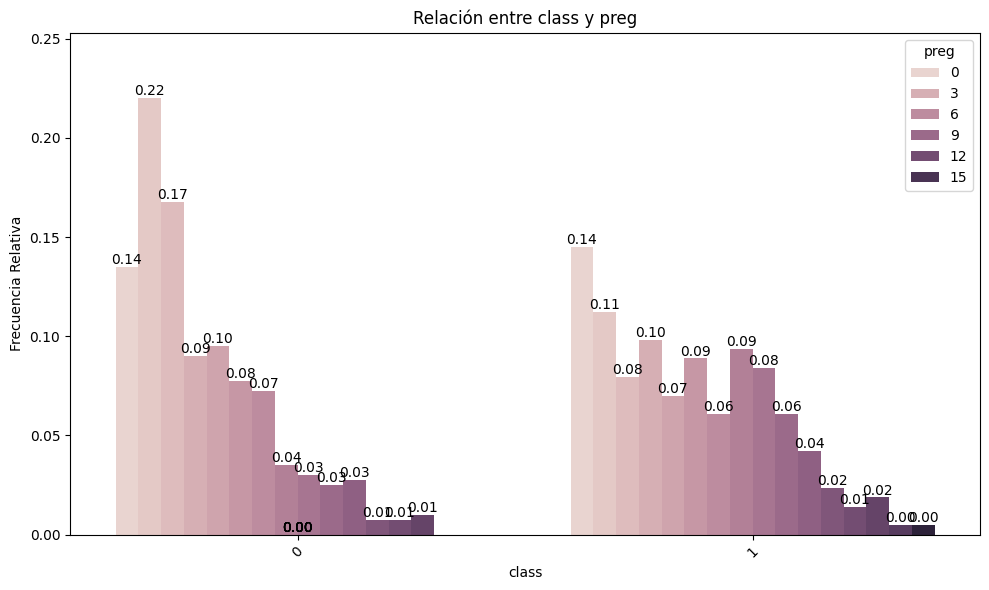

In [17]:
bt.plot_categorical_relationship(train_set, target, "preg", relative_freq=True, show_values=True)

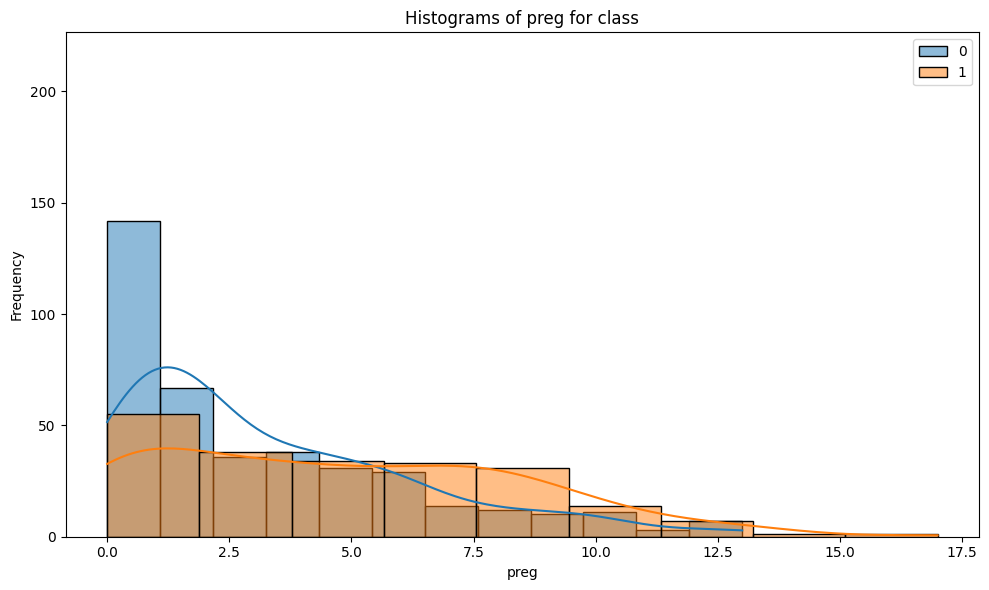

In [18]:
bt.plot_grouped_histograms(train_set, cat_col=target, num_col="preg", group_size=3)

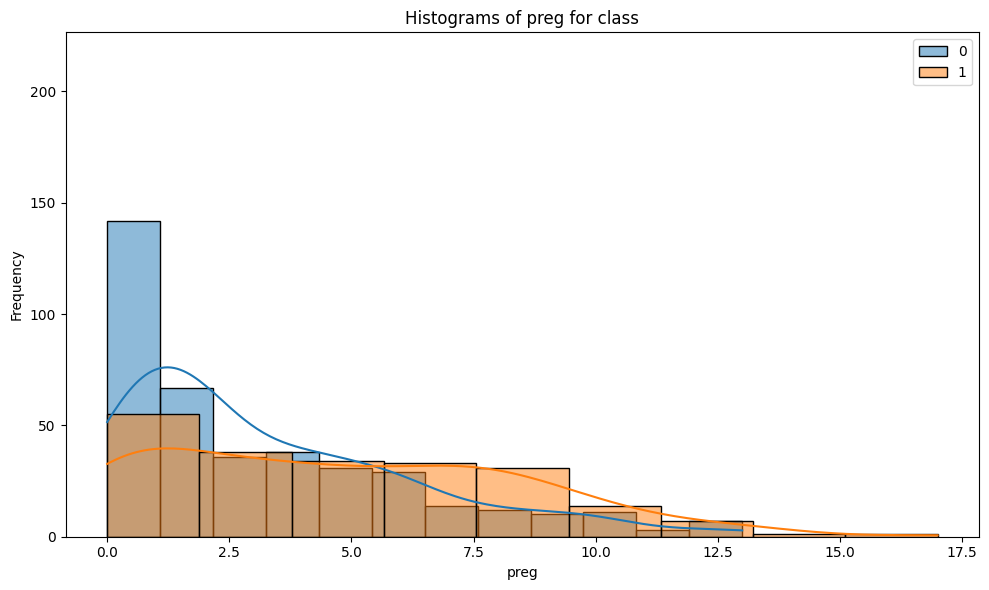

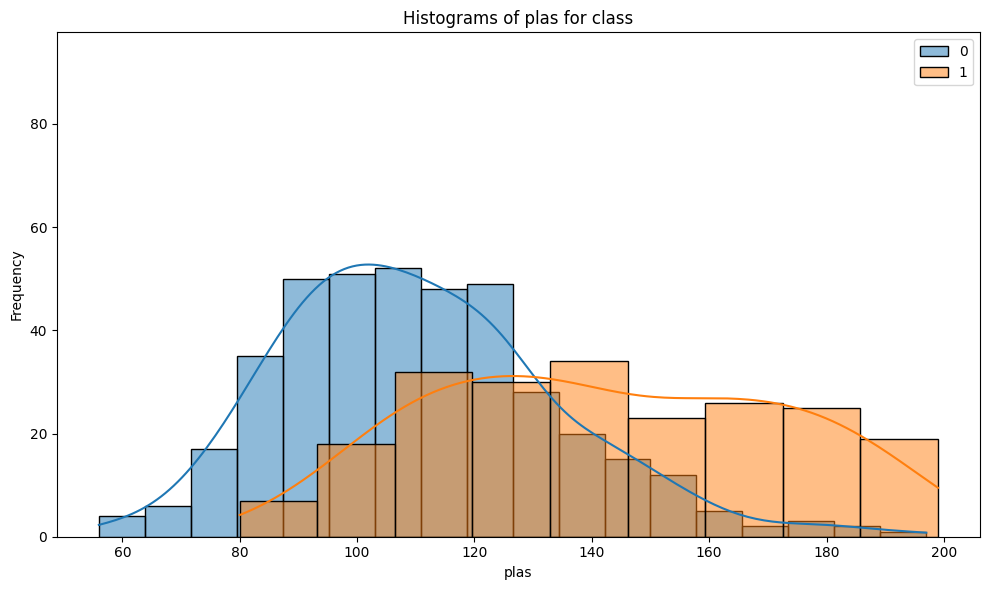

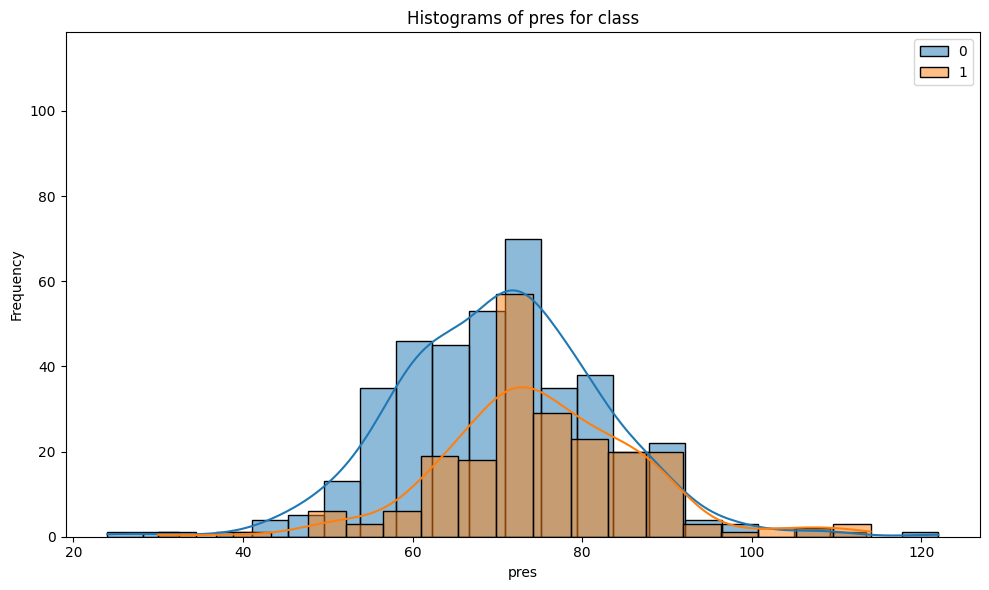

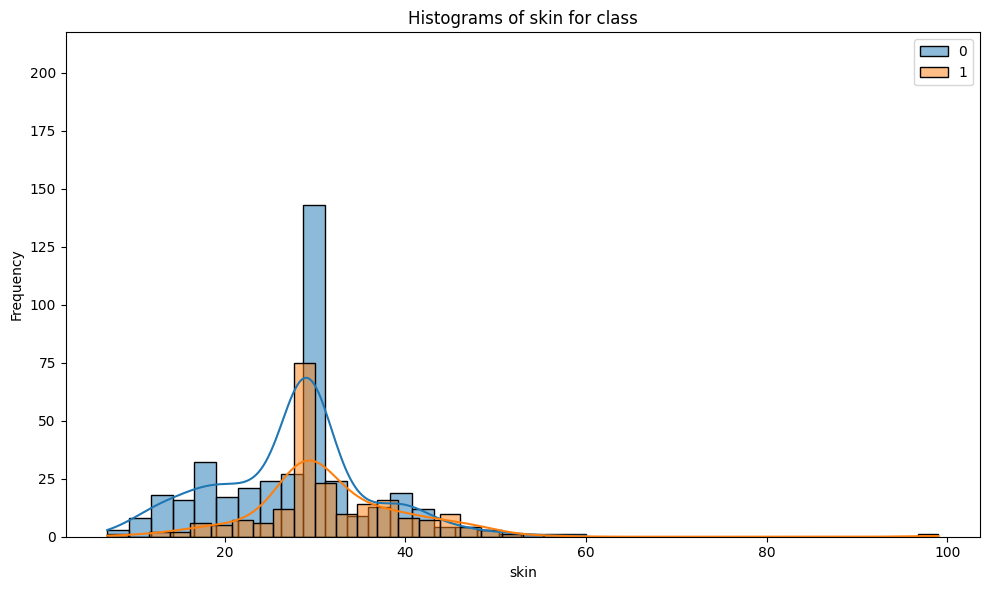

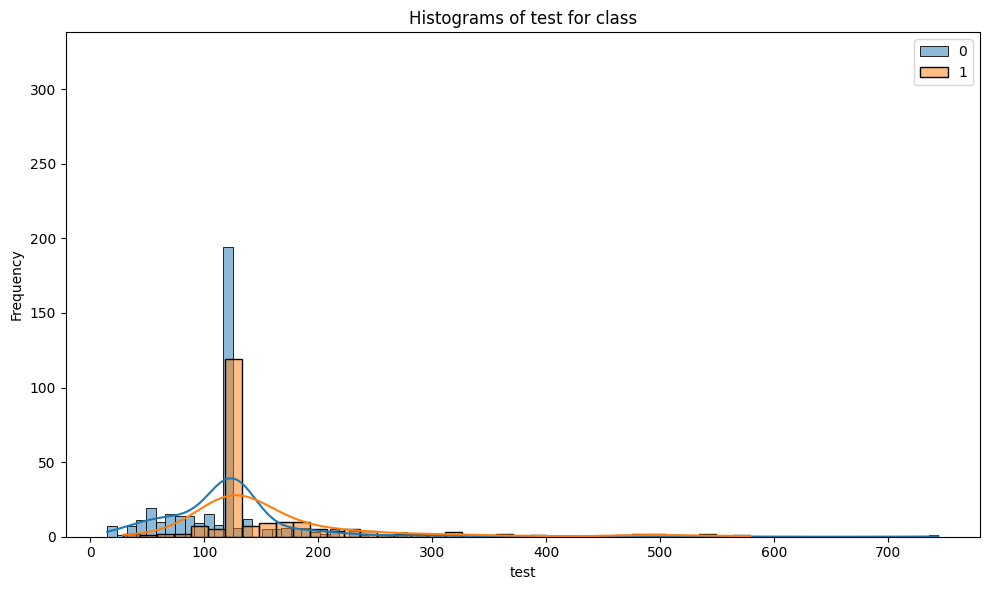

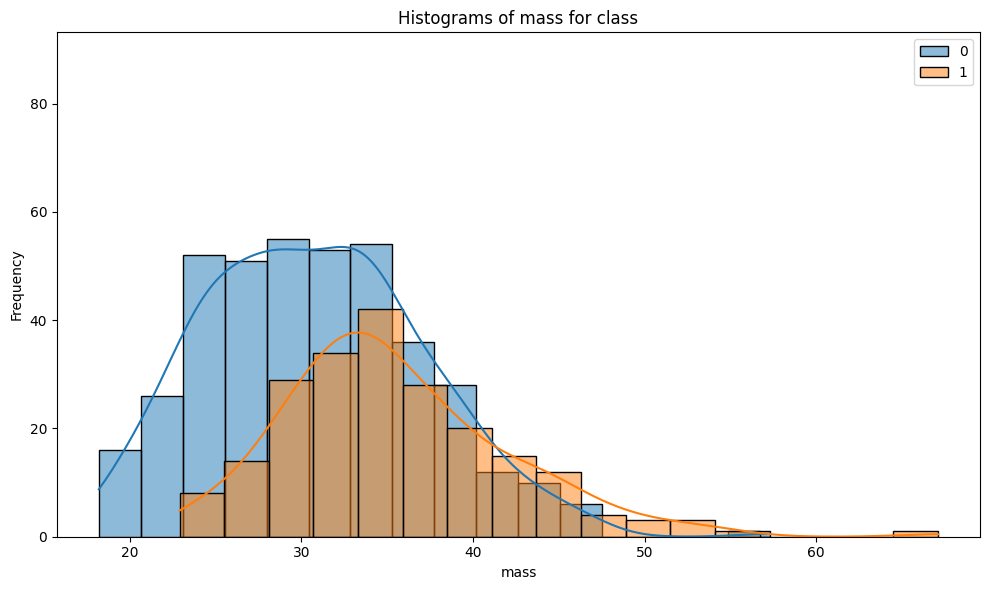

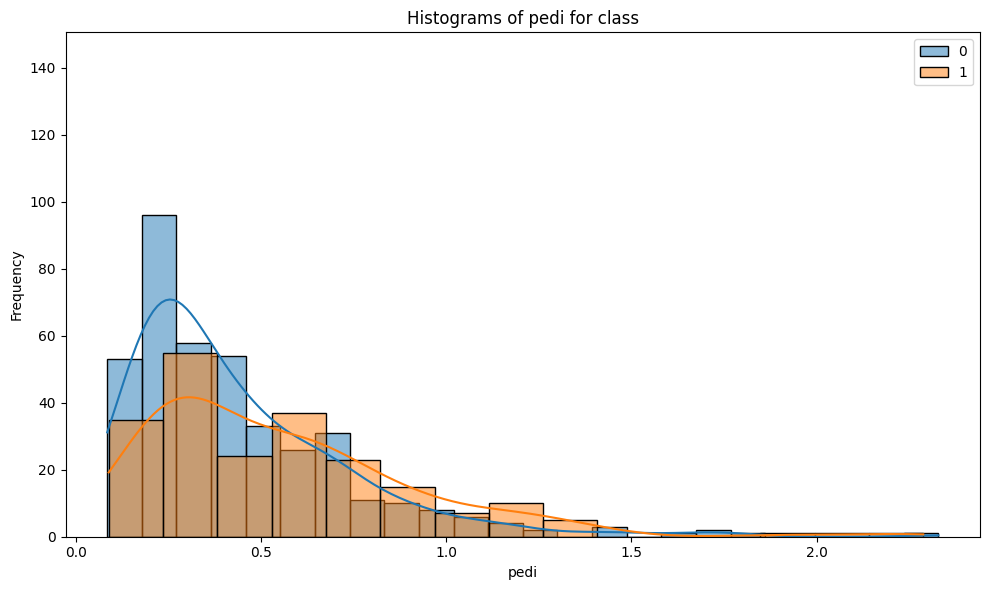

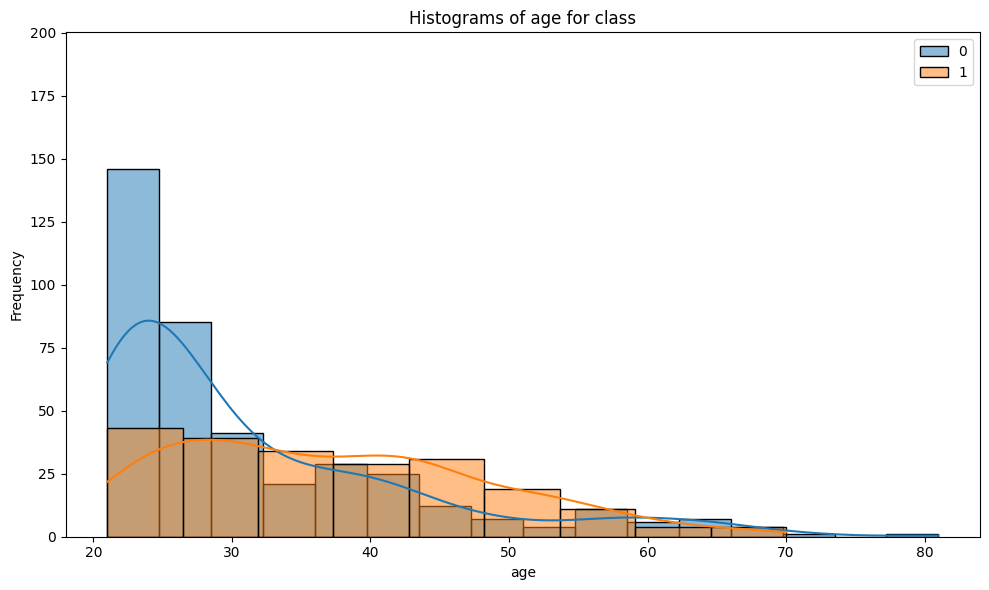

In [19]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=3)

### dividimos en X e Y

In [20]:
X_train = train_set[features_num].copy()
y_train = train_set[target]

X_test = test_set[features_num].copy()
y_test = test_set[target]

## Modelo(s) Baseline

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

base_clf = RandomForestClassifier(max_depth=5, random_state=42)

In [22]:
scores = cross_val_score(base_clf, X_train, y_train, cv=5, scoring="balanced_accuracy")
print(f"Balanced Accuracy medio (CV-5): {scores.mean():.4f} ± {scores.std():.4f}")

Balanced Accuracy medio (CV-5): 0.7175 ± 0.0364


In [23]:
base_clf.fit(X_train, y_train)
print("--- RandomForest baseline (train) ---")
print(classification_report(y_train, base_clf.predict(X_train)))

--- RandomForest baseline (train) ---
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       400
           1       0.86      0.68      0.76       214

    accuracy                           0.85       614
   macro avg       0.85      0.81      0.82       614
weighted avg       0.85      0.85      0.84       614



In [24]:
base_clf.feature_names_in_

array(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'],
      dtype=object)

In [26]:
base_clf.feature_importances_

array([0.06072573, 0.38296592, 0.04233269, 0.05339918, 0.10132026,
       0.16275494, 0.08469756, 0.11180371])

/var/folders/h9/j_cmbmlx2zx84w6mpd7n0r_00000gn/T/ipykernel_31243/2906917815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi, x="importance", y="feature", palette="viridis", ax=ax)


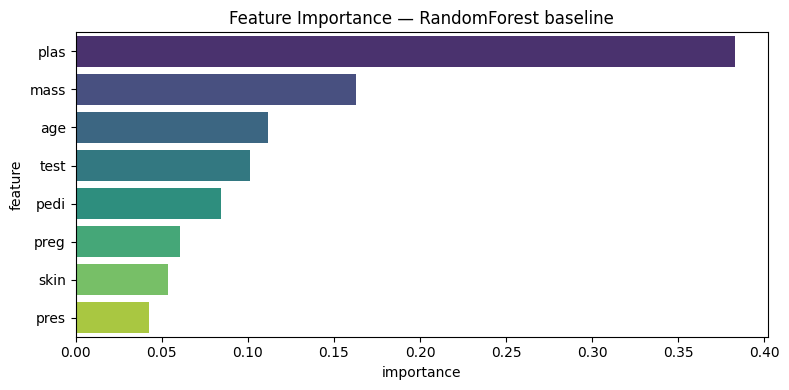

feature  importance
   plas    0.382966
   mass    0.162755
    age    0.111804
   test    0.101320
   pedi    0.084698
   preg    0.060726
   skin    0.053399
   pres    0.042333


In [27]:
df_fi = pd.DataFrame({
    "feature": base_clf.feature_names_in_,
    "importance": base_clf.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_fi, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("Feature Importance — RandomForest baseline")
plt.tight_layout()
plt.show()

print(df_fi.to_string(index=False))

### Comparación de modelos

In [28]:
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1, n_jobs=-1)

for nombre, modelo in zip(
    ["Random Forest", "XGBoost", "LightGBM"],
    [base_clf, xgb_clf, lgb_clf]
):
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy")
    print(f"{nombre:15s} | Balanced Accuracy CV-5: {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest   | Balanced Accuracy CV-5: 0.7175 ± 0.0364
XGBoost         | Balanced Accuracy CV-5: 0.6949 ± 0.0334
LightGBM        | Balanced Accuracy CV-5: 0.6877 ± 0.0244


In [29]:
ratio_clases = len(train_set[train_set[target] == 0]) / len(train_set[train_set[target] == 1])
print(f"scale_pos_weight = {ratio_clases:.4f}  (negativos/positivos en train)")

scale_pos_weight = 1.8692  (negativos/positivos en train)


### Optimización hiperparámetros

#### XGBoost

In [30]:
param_grid_xgb = {
    "n_estimators": [100, 200, 400],
    "eta": [0.1, 0.3, 0.6, 1],
    "max_depth": [1, 6, 10, 20],
    "min_child_weight": [1, 10, 20, 100],
    "scale_pos_weight": [ratio_clases, 1],
    "colsample_bytree": [0.5, 1]
}

xgb_clf = XGBClassifier(random_state=42)

xgb_grid = GridSearchCV(xgb_clf,
                        param_grid=param_grid_xgb,
                        cv=5,
                        scoring="balanced_accuracy",
                        n_jobs=-1)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...state=42, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.5, 1], 'eta': [0.1, 0.3, ...], 'max_depth': [1, 6, ...], 'min_child_weight': [1, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [31]:
xgb_grid.best_params_

{'colsample_bytree': 0.5,
 'eta': 0.1,
 'max_depth': 1,
 'min_child_weight': 20,
 'n_estimators': 100,
 'scale_pos_weight': 1.8691588785046729}

In [32]:
xgb_grid.best_score_

0.7610714285714286

In [33]:
print(classification_report(y_test, xgb_grid.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       100
           1       0.61      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.75      0.75       154



### Random Forest

In [34]:
param_grid_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth": [1, 5, 10, None],
    "min_samples_leaf": [1, 10, 20, 100],
    "class_weight": ["balanced", None],
    "max_features": ["sqrt", "log2", None]
}

rf_clf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(rf_clf,
                       param_grid=param_grid_rf,
                       cv=5,
                       scoring="balanced_accuracy",
                       n_jobs=-1)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [1, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [37]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 20,
 'n_estimators': 400}

In [35]:
rf_grid.best_score_

0.7735714285714286

In [38]:
print("--- RandomForest optimizado (test) ---")
print(classification_report(y_test, rf_grid.best_estimator_.predict(X_test)))

--- RandomForest optimizado (test) ---
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.74      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



In [39]:
param_dist_lgb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "max_depth": [3, 6, 10, -1],
    "num_leaves": [15, 31, 63, 127],
    "min_data_in_leaf": [1, 10, 20, 100],
    "class_weight": ["balanced", None],
    "max_bin": [40, 80, 200]
}

lgb_clf = LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)

lgb_grid = RandomizedSearchCV(lgb_clf,
                               param_distributions=param_dist_lgb,
                               n_iter=60,
                               cv=5,
                               scoring="balanced_accuracy",
                               random_state=42,
                               n_jobs=-1)

lgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'learning_rate': [0.01, 0.05, ...], 'max_bin': [40, 80, ...], 'max_depth': [3, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [42]:
lgb_grid.best_params_

{'num_leaves': 31,
 'n_estimators': 400,
 'min_data_in_leaf': 100,
 'max_depth': 3,
 'max_bin': 200,
 'learning_rate': 0.01,
 'class_weight': 'balanced'}

In [44]:
lgb_grid.best_score_

0.7607225913621263

In [45]:
print(classification_report(y_test, lgb_grid.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1       0.60      0.78      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



In [46]:
print("=== Balanced Accuracy en CV (sobre train) ===")
for nombre, grid in zip(["XGBoost", "RandomForest", "LightGBM"],
                        [xgb_grid, rf_grid, lgb_grid]):
    print(f"  {nombre:15s}: {grid.best_score_:.4f}")

print("\n=== Classification Report en test ===")
for nombre, grid in zip(["XGBoost", "RandomForest", "LightGBM"],
                        [xgb_grid, rf_grid, lgb_grid]):
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, grid.best_estimator_.predict(X_test)))

=== Balanced Accuracy en CV (sobre train) ===
  XGBoost        : 0.7611
  RandomForest   : 0.7736
  LightGBM       : 0.7607

=== Classification Report en test ===

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       100
           1       0.61      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.75      0.75       154


--- RandomForest ---
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.74      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154


--- LightGBM ---
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1     

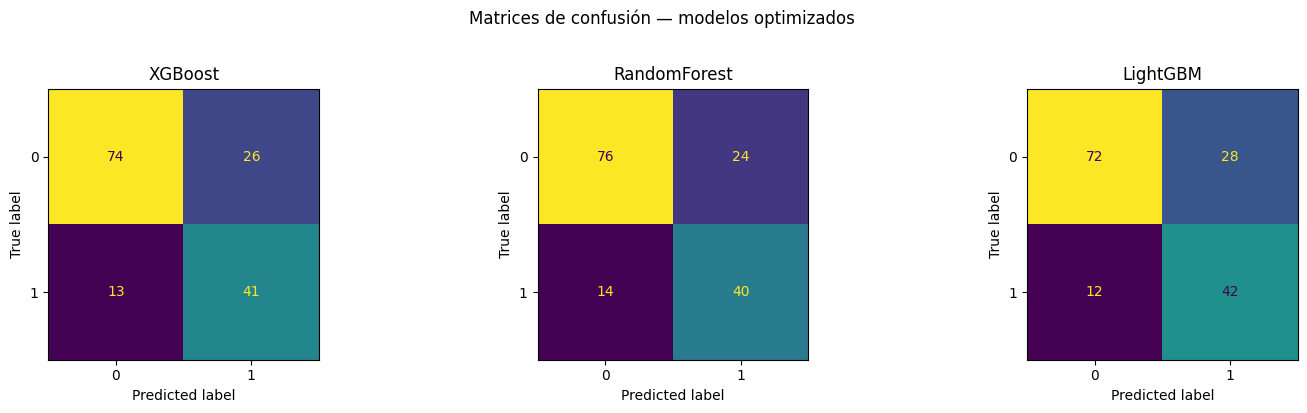

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
modelos = [xgb_grid.best_estimator_, rf_grid.best_estimator_, lgb_grid.best_estimator_]
nombres = ["XGBoost", "RandomForest", "LightGBM"]

for ax, modelo, nombre in zip(axes, modelos, nombres):
    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(nombre)

plt.suptitle("Matrices de confusión — modelos optimizados", y=1.02)
plt.tight_layout()
plt.show()
